# Model Evaluation

## Objective

The objective of this notebook is to evaluate the performance of the trained machine learning models using the unseen test dataset.

Each model will be compared using standard classification metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. The evaluation will identify the most suitable model for customer churn prediction.

## Import Libraries

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

plt.style.use("ggplot")

## Load Test Dataset

In [ ]:
test_df = pd.read_csv("../../../data/processed/customer_churn_data/churn_test.csv")

X_test = test_df.drop(columns="churn")

y_test = test_df["churn"]

## Load Scaler

In [18]:
scaler = joblib.load(
    "../../model/churn_prediction/robust_scaler.pkl"
)

In [19]:
X_test_scaled = scaler.transform(X_test)

## Load trained Models

In [20]:
lr = joblib.load("../../model/churn_prediction/logistic_regression.pkl")

dt = joblib.load("../../model/churn_prediction/decision_tree.pkl")

rf = joblib.load("../../model/churn_prediction/random_forest.pkl")

xgb = joblib.load("../../model/churn_prediction/xgboost.pkl")

In [21]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

## Evaluate the models

In [22]:
results = []

In [23]:
for name, model in models.items():

    if name == "Logistic Regression":
        predictions = model.predict(X_test_scaled)
        probabilities = model.predict_proba(X_test_scaled)[:,1]

    else:
        predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)[:,1]

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions),

        "ROC AUC": roc_auc_score(y_test, probabilities)

    })

## Comparision Table

In [24]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC AUC", ascending=False)
)
results_df.iloc[:,1:] = results_df.iloc[:,1:].round(4)


results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,XGBoost,0.9985,0.9946,0.9989,0.9967,1.0000
0,Logistic Regression,0.6461,0.3963,1.0000,0.5676,0.8687


## Barchart Comparision

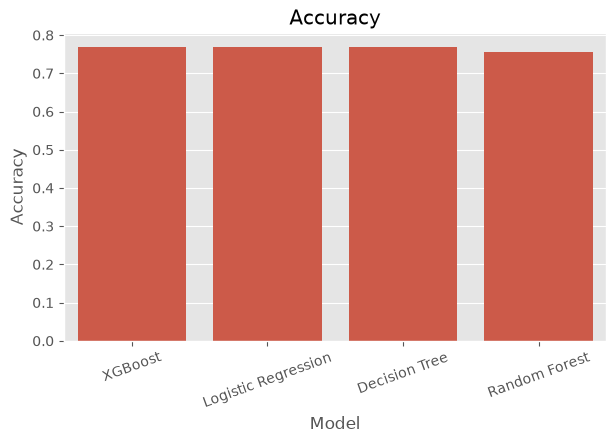

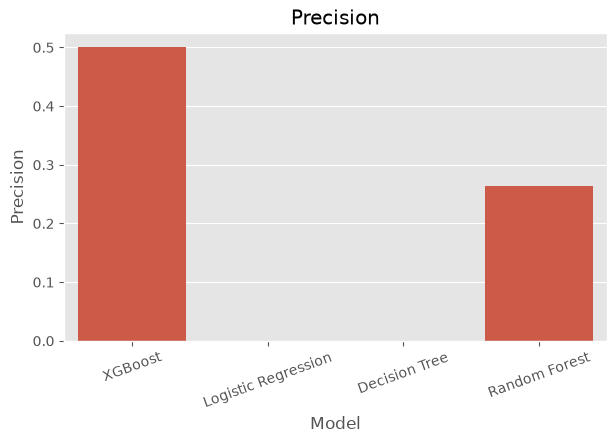

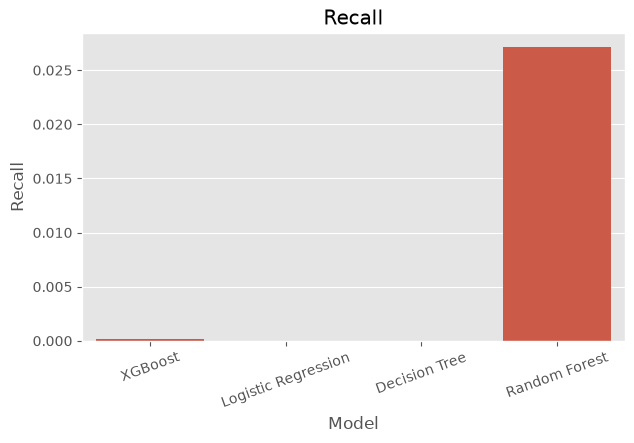

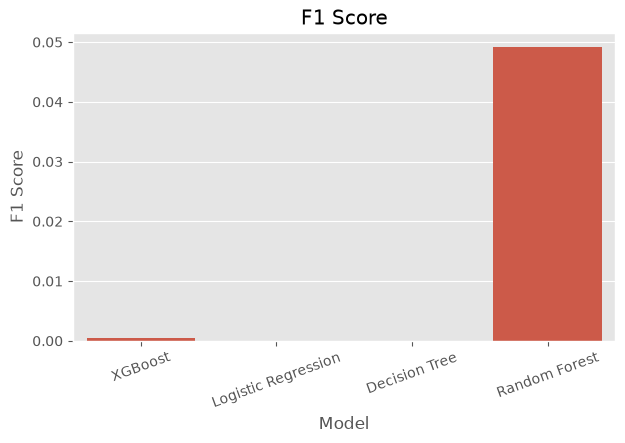

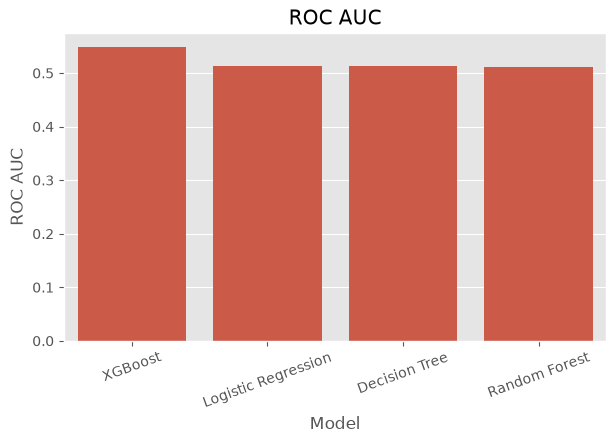

In [12]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

for metric in metrics:

    plt.figure(figsize=(7,4))

    sns.barplot(
        data=results_df,
        x="Model",
        y=metric
    )

    plt.title(metric)

    plt.xticks(rotation=20)

    plt.show()

In [13]:
from sklearn.metrics import confusion_matrix

pred = xgb.predict(X_test)

cm = confusion_matrix(y_test, pred)

print(cm)

[[14650     1]
 [ 4432     1]]


In [15]:
pred = xgb.predict(X_test)

print(pd.Series(pred).value_counts())

0    19082
1        2
Name: count, dtype: int64
